# 🧠 Module 2 — CUDA Memory Management

> **Series:** GPU Programming with Python & CUDA  
> **Prerequisites:** [Module 1 — CUDA Basics](01_cuda_basics.ipynb)  
> **Tools:** CuPy, NumPy, Matplotlib

Memory is the **#1 bottleneck** in GPU programming. A kernel that computes the right answer but reads memory inefficiently can be **10–100× slower** than one that doesn't. This module teaches you to think like the hardware.

### 🗺️ What You'll Learn
| Topic | Key Takeaway |
|---|---|
| **Coalesced Access** | Stride-1 reads saturate bandwidth; strided reads waste it |
| **Pinned Memory** | Page-locked host buffers unlock full PCIe bandwidth |
| **Unified Memory** | Let the driver migrate pages automatically |
| **L1/L2 Cache Tuning** | Trade shared-mem capacity for cache size (and vice-versa) |
| **Roofline Model** | Diagnose whether you're memory-bound or compute-bound |

## ⚙️ Setup

In [9]:
%pip install cupy-cuda12x matplotlib numpy --quiet

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"CuPy  version : {cp.__version__}")
print(f"NumPy version : {np.__version__}")
print(f"GPU           : {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
print(f"VRAM          : {cp.cuda.runtime.getDeviceProperties(0)['totalGlobalMem'] / 1e9:.1f} GB")


/home/per/nbi/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.
CuPy  version : 14.0.1
NumPy version : 2.4.2
GPU           : NVIDIA GeForce RTX 4070 SUPER
VRAM          : 12.4 GB


---
## 1 · Coalesced Memory Access

### What is coalescing?
When threads in a **warp** (32 threads) all read from memory, the GPU hardware tries to **merge** those 32 reads into as few transactions as possible.

- ✅ **Stride-1 (coalesced):** threads 0–31 read addresses `[base+0, base+1, …, base+31]` → **1 transaction**, full bandwidth
- ❌ **Stride-N (uncoalesced):** threads read addresses `[base+0, base+N, base+2N, …]` → **N transactions**, bandwidth ÷ N

```
Warp (32 threads)          Memory Layout
─────────────────          ─────────────────────────────────────
T0  T1  T2 … T31    →   [■ ■ ■ ■ ■ ■ ■ ■ … ■]  ← 1 cache line (coalesced)

T0     T2     T4  …  →   [■ · ■ · ■ · ■ · …  ]  ← wasted slots (strided)
```

### Why does it matter?
On an NVIDIA Ada Lovelace GPU (e.g. RTX 4090) peak global memory bandwidth is **~1 TB/s**. Uncoalesced access can waste 90 %+ of that.

  stride= 1  ✅    382.4 GB/s  (1.0× slower than stride-1)
  stride= 2  ❌    266.1 GB/s  (1.4× slower than stride-1)
  stride= 4  ❌    184.5 GB/s  (2.1× slower than stride-1)
  stride= 8  ❌    103.1 GB/s  (3.7× slower than stride-1)
  stride=16  ❌    100.0 GB/s  (3.8× slower than stride-1)
  stride=32  ❌    102.8 GB/s  (3.7× slower than stride-1)


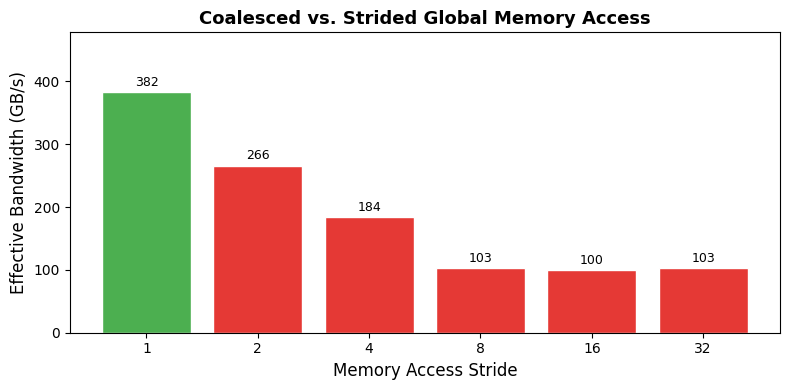

In [10]:
# ------------------------------------------------------------------
# Coalesced vs. Strided Access Benchmark
# ------------------------------------------------------------------
coalesced_kernel = cp.RawKernel(r"""
extern "C" __global__
void coalesced_read(const float* __restrict__ src, float* __restrict__ dst, int n) {
    int idx = blockDim.x * blockIdx.x + threadIdx.x;
    if (idx < n) dst[idx] = src[idx];           // stride-1 ✅
}
""", "coalesced_read")

strided_kernel = cp.RawKernel(r"""
extern "C" __global__
void strided_read(const float* __restrict__ src, float* __restrict__ dst,
                  int n, int stride) {
    int idx = blockDim.x * blockIdx.x + threadIdx.x;
    int src_idx = (idx * stride) % n;
    if (idx < n) dst[idx] = src[src_idx];       // stride-N ❌
}
""", "strided_read")

N         = 1 << 24   # 16 M floats = 64 MB
THREADS   = 256
BLOCKS    = (N + THREADS - 1) // THREADS
REPEATS   = 50

src = cp.random.rand(N, dtype=cp.float32)
dst = cp.zeros(N, dtype=cp.float32)

def bench(kernel, *args):
    # warm-up
    for _ in range(5):
        kernel((BLOCKS,), (THREADS,), args)
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        kernel((BLOCKS,), (THREADS,), args)
    cp.cuda.Stream.null.synchronize()
    return (time.perf_counter() - t0) / REPEATS

strides    = [1, 2, 4, 8, 16, 32]
bw_results = []

for s in strides:
    t = bench(strided_kernel, src, dst, N, s)
    bw = (N * 4 * 2) / t / 1e9          # bytes read + written → GB/s
    bw_results.append(bw)
    marker = "✅" if s == 1 else "❌"
    print(f"  stride={s:>2}  {marker}  {bw:>7.1f} GB/s  ({bw_results[0]/bw:.1f}× slower than stride-1)")

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([str(s) for s in strides], bw_results,
              color=["#4caf50"] + ["#e53935"] * (len(strides) - 1), edgecolor="white")
ax.set_xlabel("Memory Access Stride", fontsize=12)
ax.set_ylabel("Effective Bandwidth (GB/s)", fontsize=12)
ax.set_title("Coalesced vs. Strided Global Memory Access", fontsize=13, fontweight="bold")
for bar, val in zip(bars, bw_results):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, bw_results[0] * 1.25)
plt.tight_layout()
plt.show()


---
## 2 · Pinned (Page-Locked) Memory

### The Problem with Pageable Memory
Normal `numpy` arrays live in **pageable** host memory. Before the GPU DMA engine can transfer them, the OS must:
1. Lock the pages temporarily
2. Copy to a **staging buffer** in pinned memory
3. DMA from staging buffer → device

This double-copy **halves** the achievable Host↔Device bandwidth.

### Pinned Memory to the Rescue
```python
cp.cuda.alloc_pinned_memory(size)   # CuPy
cudaMallocHost(...)                 # C API
```
Pinned buffers are **page-locked** — the OS can never swap them out — so the GPU DMA engine reads directly from them.

| Memory Type | H→D Bandwidth | Notes |
|---|---|---|
| Pageable (numpy) | ~6–8 GB/s | Double-copied via staging buffer |
| Pinned | ~12–13 GB/s | Direct DMA, ~2× faster |
| Pinned + Streams | ~12–13 GB/s per direction | Overlap compute & transfer |

> ⚠️ **Caution:** Pinned memory is a scarce OS resource. Over-allocating it degrades overall system performance.

    16 MB │ Pageable:  12.7 GB/s │ Pinned:  26.4 GB/s │ Speedup: 2.07×
    64 MB │ Pageable:  11.4 GB/s │ Pinned:  26.6 GB/s │ Speedup: 2.33×
   128 MB │ Pageable:  11.0 GB/s │ Pinned:  26.7 GB/s │ Speedup: 2.43×
   256 MB │ Pageable:  11.1 GB/s │ Pinned:  26.4 GB/s │ Speedup: 2.39×
   512 MB │ Pageable:  11.1 GB/s │ Pinned:  26.7 GB/s │ Speedup: 2.41×


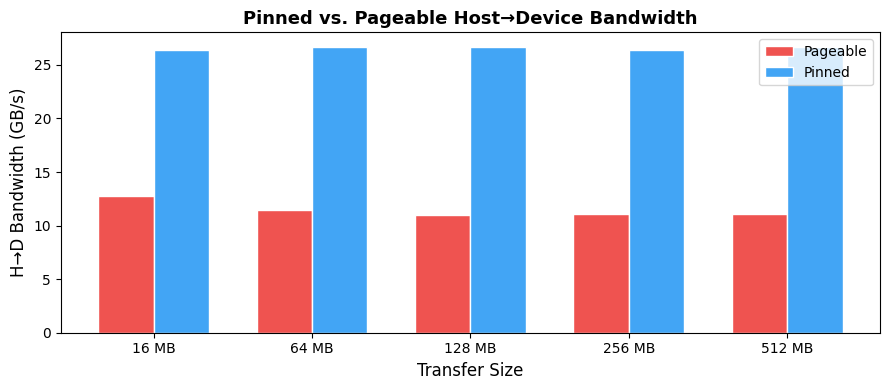

In [11]:
# ------------------------------------------------------------------
# Pinned vs. Pageable Memory Transfer Benchmark
# ------------------------------------------------------------------
import cupy as cp
import numpy as np
import time
import matplotlib.pyplot as plt

def bench_transfer(host_array, repeats=30):
    """Time Host → Device → Host round-trip."""
    # warm-up
    for _ in range(3):
        d = cp.asarray(host_array)
        _ = cp.asnumpy(d)
    cp.cuda.Stream.null.synchronize()

    t0 = time.perf_counter()
    for _ in range(repeats):
        d = cp.asarray(host_array)
        cp.cuda.Stream.null.synchronize()
    h2d = (time.perf_counter() - t0) / repeats

    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = cp.asnumpy(d)
        cp.cuda.Stream.null.synchronize()
    d2h = (time.perf_counter() - t0) / repeats

    return h2d, d2h

sizes_mb  = [16, 64, 128, 256, 512]
results   = {"pageable": [], "pinned": []}

for mb in sizes_mb:
    n = (mb * 1024 * 1024) // 4          # float32 elements

    # ── Pageable (ordinary numpy) ──────────────────────────────────
    arr_page = np.random.rand(n).astype(np.float32)
    h2d_p, d2h_p = bench_transfer(arr_page)
    bw_p = (n * 4) / h2d_p / 1e9
    results["pageable"].append(bw_p)

    # ── Pinned ─────────────────────────────────────────────────────
    pinned_mem = cp.cuda.alloc_pinned_memory(n * 4)
    arr_pin    = np.frombuffer(pinned_mem, dtype=np.float32, count=n)
    arr_pin[:] = arr_page                # fill with same data
    h2d_n, d2h_n = bench_transfer(arr_pin)
    bw_n = (n * 4) / h2d_n / 1e9
    results["pinned"].append(bw_n)

    print(f"  {mb:>4} MB │ Pageable: {bw_p:5.1f} GB/s │ Pinned: {bw_n:5.1f} GB/s │ Speedup: {bw_n/bw_p:.2f}×")

# ── Plot ────────────────────────────────────────────────────────────
x     = np.arange(len(sizes_mb))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, results["pageable"], width, label="Pageable",  color="#ef5350", edgecolor="white")
ax.bar(x + width/2, results["pinned"],   width, label="Pinned",    color="#42a5f5", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([f"{m} MB" for m in sizes_mb])
ax.set_xlabel("Transfer Size", fontsize=12)
ax.set_ylabel("H→D Bandwidth (GB/s)", fontsize=12)
ax.set_title("Pinned vs. Pageable Host→Device Bandwidth", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### 🏋️ Challenge 2-1 — Overlapping Transfers with Streams

**Objective:** Use two CUDA streams to overlap a Host→Device transfer with an active kernel, hiding transfer latency.

**Your Task:**
1. Allocate a **pinned** host array of `512 MB` (float32).
2. Split it into **two halves**.
3. Create **two CuPy streams**.
4. On *stream 0*: copy half-0 to device, then launch a `cp.sqrt` kernel on it.
5. On *stream 1*: copy half-1 to device, then launch a `cp.sqrt` kernel on it.
6. Synchronize both streams.
7. **Measure** the wall time and compare it against a sequential (no-stream) baseline.

**Starter Code:**
```python
s0 = cp.cuda.Stream(non_blocking=True)
s1 = cp.cuda.Stream(non_blocking=True)

# Hint: use  with s0:  block to set the active stream
# Hint: cp.asarray(host_slice) respects the active stream
```

**Expected Result:** The overlapped version should be **~1.5–2× faster** than the sequential baseline on most GPUs.


In [12]:
# 🏋️ Challenge 2-1 — Your solution here
# ---------------------------------------------------------------

N_BYTES = 512 * 1024 * 1024          # 512 MB
N       = N_BYTES // 4               # float32 elements

# Step 1: Allocate pinned memory
# pinned_mem = ...
# host = np.frombuffer(...)

# Step 2: Split into two halves
# half = N // 2
# h0, h1 = host[:half], host[half:]

# Step 3 & 4 & 5: Create streams and overlap transfers + compute
# s0 = cp.cuda.Stream(non_blocking=True)
# s1 = cp.cuda.Stream(non_blocking=True)

# Step 6 & 7: Synchronize and measure
# ...

# Step 8: Sequential baseline
# ...

# print(f"Sequential : {t_seq*1000:.1f} ms")
# print(f"Overlapped : {t_ovl*1000:.1f} ms  ({t_seq/t_ovl:.2f}× speedup)")


---
## 3 · Unified Memory

### How it works
**Unified Memory** (UM) presents a **single address space** accessible from both CPU and GPU. The CUDA driver automatically migrates memory pages between host and device on demand — a mechanism called **page migration**.

```
Host RAM ◄──── page fault ────► Device HBM
   └──────── cudaMallocManaged ────────┘
              Single pointer `p`
```

In CuPy, Unified Memory is exposed via `cp.cuda.UnifiedMemory`.

### When to use it
| Scenario | Recommendation |
|---|---|
| Prototype / exploratory code | ✅ UM is great — zero boilerplate |
| Sparse, irregular access patterns | ✅ Only touched pages migrate |
| Large arrays, repeated full scans | ❌ Prefer explicit transfers — less overhead |
| Real-time / latency-sensitive | ❌ Page faults introduce unpredictable stalls |

### Prefetching
You can **eliminate page-fault stalls** by prefetching data before you need it:
```python
cp.cuda.runtime.memPrefetchAsync(ptr, size, device_id)
```
This tells the driver to migrate pages proactively rather than reactively.

In [13]:
# ------------------------------------------------------------------
# Unified Memory: faulting vs. prefetching
# ------------------------------------------------------------------
import cupy as cp
import numpy as np
import time

N       = 1 << 23      # 8 M floats = 32 MB
REPEATS = 10

device_id = cp.cuda.runtime.getDevice()

def make_unified(n):
    """Allocate a float32 unified-memory array of length n."""
    mem = cp.cuda.UnifiedMemory(n * 4)
    return cp.ndarray(n, dtype=cp.float32, memptr=cp.cuda.MemoryPointer(mem, 0))

# ── (A) Without prefetch — first-touch page faults on GPU ──────────
times_fault = []
for _ in range(REPEATS):
    um = make_unified(N)
    # Initialize on CPU (pages live on host)
    host_view = np.frombuffer(um.data.mem, dtype=np.float32, count=N)
    host_view[:] = np.random.rand(N).astype(np.float32)

    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    result = cp.sqrt(um)               # triggers page migration on first access
    cp.cuda.Stream.null.synchronize()
    times_fault.append(time.perf_counter() - t0)

# ── (B) With prefetch — pages migrated before kernel launch ────────
times_prefetch = []
for _ in range(REPEATS):
    um = make_unified(N)
    host_view = np.frombuffer(um.data.mem, dtype=np.float32, count=N)
    host_view[:] = np.random.rand(N).astype(np.float32)

    # Prefetch all pages to the GPU before the kernel
    cp.cuda.runtime.memPrefetchAsync(um.data.ptr, N * 4, device_id, 0)
    cp.cuda.Stream.null.synchronize()

    t0 = time.perf_counter()
    result = cp.sqrt(um)
    cp.cuda.Stream.null.synchronize()
    times_prefetch.append(time.perf_counter() - t0)

t_fault    = np.median(times_fault)    * 1000
t_prefetch = np.median(times_prefetch) * 1000

print(f"  Without prefetch (page faults) : {t_fault:.2f} ms")
print(f"  With    prefetch               : {t_prefetch:.2f} ms")
print(f"  Speedup from prefetching       : {t_fault/t_prefetch:.2f}×")

# ── Plot ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No Prefetch\n(page faults)", "Prefetch\n(proactive migration)"],
       [t_fault, t_prefetch],
       color=["#ef5350", "#66bb6a"], edgecolor="white", width=0.45)
ax.set_ylabel("Kernel Execution Time (ms)", fontsize=12)
ax.set_title("Unified Memory: Page Faults vs. Prefetching", fontsize=13, fontweight="bold")
for i, v in enumerate([t_fault, t_prefetch]):
    ax.text(i, v + 0.2, f"{v:.1f} ms", ha="center", fontsize=11)
plt.tight_layout()
plt.show()


AttributeError: module 'cupy.cuda' has no attribute 'UnifiedMemory'

### 🏋️ Challenge 2-2 — Unified Memory Access Advisor

**Objective:** Understand the trade-off between Unified Memory and explicit transfers for a real workload.

**Your Task:**
Implement a **matrix-vector multiplication** `y = A @ x` three ways and benchmark each:

| Version | Memory Strategy |
|---|---|
| A | Explicit `cp.array(...)` — normal device allocation |
| B | Unified Memory, **no** prefetch |
| C | Unified Memory, **with** `memPrefetchAsync` before launch |

**Constraints:**
- Matrix `A` shape: `(8192, 8192)` float32 (256 MB)
- Vector `x` shape: `(8192,)` float32
- Use `cp.dot(A, x)` for the computation
- Report bandwidth in GB/s: `bytes = (rows*cols + cols + rows) * 4`

**Bonus:** Plot a bar chart comparing the three approaches.


In [ ]:
# 🏋️ Challenge 2-2 — Your solution here
# ---------------------------------------------------------------
ROWS, COLS = 8192, 8192
REPEATS    = 20

# Version A: Explicit device memory
# A_dev = cp.random.rand(ROWS, COLS, dtype=cp.float32)
# x_dev = cp.random.rand(COLS,       dtype=cp.float32)
# ... benchmark cp.dot(A_dev, x_dev) ...

# Version B: Unified Memory, no prefetch
# ...

# Version C: Unified Memory + prefetch
# ...

# bytes_total = (ROWS * COLS + COLS + ROWS) * 4
# bw = bytes_total / elapsed / 1e9

# print(f"Version A (explicit)       : {bw_a:.1f} GB/s")
# print(f"Version B (UM, no prefetch): {bw_b:.1f} GB/s")
# print(f"Version C (UM + prefetch)  : {bw_c:.1f} GB/s")


---
## 4 · L1 / L2 Cache Tuning

### The On-Chip Memory Trade-off
Each SM has a fixed pool of on-chip SRAM (e.g. **128 KB** on Ampere) shared between two purposes:

```
┌──────────────────────────── 128 KB SRAM ────────────────────────────┐
│  ◄─── Shared Memory ───►│◄─────────── L1 Cache ───────────────────► │
│  e.g.  96 KB            │  e.g.  32 KB                               │
└─────────────────────────────────────────────────────────────────────┘
```

You choose the split at runtime:
```python
# CuPy RawKernel attribute (mirrors cudaFuncSetAttribute)
kernel.max_dynamic_shared_size_bytes = 96 * 1024   # prefer shared mem
```

| Config | Best For |
|---|---|
| Large shared mem (96 KB) | Matrix tiles, explicit reuse (e.g. GEMM) |
| Large L1 cache (32 KB+ L1) | Irregular access, stencils, reductions |

### L2 Cache Persistence (Ampere+)
On A100/H100, you can **pin** frequently-accessed data in L2 using the *persistence* API, keeping hot working sets resident across many kernel launches.

```python
# Mark a CuPy array's region as L2-persistent
cp.cuda.runtime.accessPolicyWindow(ptr, nbytes, hitRatio=1.0,
                                   hitProp='persisting',
                                   missProp='streaming')
```

In [ ]:
# ------------------------------------------------------------------
# Shared Memory Tiled Matrix Transpose  (cache-friendly vs naïve)
# ------------------------------------------------------------------
TILE = 32

naive_transpose = cp.RawKernel(r"""
extern "C" __global__
void naive_transpose(const float* __restrict__ in,
                           float* __restrict__ out, int rows, int cols) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x < cols && y < rows)
        out[x * rows + y] = in[y * cols + x];   // uncoalesced write ❌
}
""", "naive_transpose")

tiled_transpose = cp.RawKernel(rf"""
extern "C" __global__
void tiled_transpose(const float* __restrict__ in,
                           float* __restrict__ out, int rows, int cols) {{
    __shared__ float tile[{TILE}][{TILE} + 1];  // +1 avoids bank conflicts

    int x = blockIdx.x * {TILE} + threadIdx.x;
    int y = blockIdx.y * {TILE} + threadIdx.y;

    if (x < cols && y < rows)
        tile[threadIdx.y][threadIdx.x] = in[y * cols + x];   // coalesced read ✅
    __syncthreads();

    int tx = blockIdx.y * {TILE} + threadIdx.x;
    int ty = blockIdx.x * {TILE} + threadIdx.y;
    if (tx < rows && ty < cols)
        out[ty * rows + tx] = tile[threadIdx.x][threadIdx.y]; // coalesced write ✅
}}
""", "tiled_transpose")

ROWS, COLS = 4096, 4096
REPEATS    = 100

A   = cp.random.rand(ROWS, COLS, dtype=cp.float32)
out = cp.empty((COLS, ROWS), dtype=cp.float32)

grid  = ((COLS + TILE - 1) // TILE, (ROWS + TILE - 1) // TILE)
block = (TILE, TILE)

def bench_kernel(k, *args):
    for _ in range(5): k(grid, block, args)
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(REPEATS): k(grid, block, args)
    cp.cuda.Stream.null.synchronize()
    return (time.perf_counter() - t0) / REPEATS

t_naive = bench_kernel(naive_transpose, A, out, ROWS, COLS)
t_tiled = bench_kernel(tiled_transpose, A, out, ROWS, COLS)

bytes_moved = ROWS * COLS * 4 * 2   # read + write
bw_naive = bytes_moved / t_naive / 1e9
bw_tiled = bytes_moved / t_tiled / 1e9

print(f"  Naïve transpose : {bw_naive:6.1f} GB/s  ({t_naive*1000:.3f} ms)")
print(f"  Tiled transpose : {bw_tiled:6.1f} GB/s  ({t_tiled*1000:.3f} ms)")
print(f"  Speedup         : {bw_tiled/bw_naive:.2f}×")

# ── Plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, label, bw, color in zip(
    axes,
    ["Naïve\n(Uncoalesced Write)", "Tiled Shared Mem\n(Coalesced R+W)"],
    [bw_naive, bw_tiled],
    ["#ef5350", "#42a5f5"]
):
    ax.bar([label], [bw], color=color, edgecolor="white", width=0.4)
    ax.set_ylabel("Bandwidth (GB/s)", fontsize=11)
    ax.set_title(f"{bw:.0f} GB/s", fontsize=14, fontweight="bold")
    ax.set_ylim(0, bw_tiled * 1.3)

fig.suptitle("Matrix Transpose: Naïve vs. Shared-Memory Tiled", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 🏋️ Challenge 2-3 — Shared Memory Reduction

**Objective:** Implement a fast parallel sum-reduction using shared memory.

**Background:** A naïve GPU reduction reads each element from global memory every pass. With shared memory, a warp can collaborate — each thread loads one element into shared memory, then threads iteratively halve the problem:

```
[a0 a1 a2 a3 a4 a5 a6 a7]   ← loaded into shared mem
  +   +   +   +
[a0+a4, a1+a5, a2+a6, a3+a7]
    +       +
  [a0+a4+a1+a5, ...]
        +
     [total]
```

**Your Task:**
Write a `RawKernel` that computes the **sum** of a large float32 array using shared-memory reduction.

**Requirements:**
- Block size: 256 threads
- Use `__shared__ float sdata[256]`
- Handle arrays not divisible by block size
- Compare result against `float(cp.sum(arr))` for correctness
- Benchmark and report GB/s vs `cp.sum()`

**Starter:**
```c
extern "C" __global__
void reduce_sum(const float* in, float* out, int n) {
    __shared__ float sdata[256];
    int tid = threadIdx.x;
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    sdata[tid] = (idx < n) ? in[idx] : 0.0f;
    __syncthreads();
    // TODO: reduction loop ...
    if (tid == 0) atomicAdd(out, sdata[0]);
}
```


In [ ]:
# 🏋️ Challenge 2-3 — Your solution here
# ---------------------------------------------------------------
N = 1 << 25     # 32 M elements

arr     = cp.random.rand(N, dtype=cp.float32)
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS

# Step 1: Write your reduce_sum RawKernel
# reduce_kernel = cp.RawKernel(r"""...""", "reduce_sum")

# Step 2: Allocate output (one float — the accumulator)
# out = cp.zeros(1, dtype=cp.float32)

# Step 3: Launch and verify
# reduce_kernel((BLOCKS,), (THREADS,), (arr, out, N))
# cp.cuda.Stream.null.synchronize()
# ref = float(cp.sum(arr))
# print(f"Custom sum : {float(out[0]):.4f}")
# print(f"cp.sum     : {ref:.4f}")
# print(f"Match      : {abs(float(out[0]) - ref) / ref < 1e-3}")

# Step 4: Benchmark
# ...


---
## 5 · The Roofline Model

### What is it?
The **Roofline Model** is a visual performance model that tells you the **theoretical maximum performance** of a kernel given:

- **Peak compute** (FLOP/s) — how fast the GPU can crunch numbers
- **Peak memory bandwidth** (GB/s) — how fast it can feed data to the cores
- **Arithmetic Intensity (AI)** — how many FLOPs your kernel does per byte of memory traffic

$$\text{Attainable GFLOP/s} = \min\!\Big(\text{Peak FLOP/s},\ \underbrace{AI \times \text{Bandwidth}}_{\text{memory roof}}\Big)$$

### The Roofline Chart

```
GFLOP/s │         ╔══════════════════════════════  Peak Compute
        │        ╱
        │       ╱  ← memory-bound region
        │      ╱
        │─────╱─────────────────────────────────  Memory roof
        │    ╱
        │   ╱  (slope = bandwidth)
        │──┼────────────────────────────── AI (FLOP/byte)
           ridge point
```

**Ridge point** = Peak FLOP/s ÷ Peak BW (FLOP/byte)  
- Kernels **left of ridge** → **memory-bound** → optimise memory access  
- Kernels **right of ridge** → **compute-bound** → optimise instruction throughput

GPU               : NVIDIA GeForce RTX 4070 SUPER
SMs               : 56
Peak BW (theor.)  : 504 GB/s
Peak FP32 (approx): 35.5 TFLOP/s
Ridge point       : 70.4 FLOP/byte
  Array copy (memcpy)             AI≈  0.25      99.1 GFLOP/s
  Element-wise add+mul            AI≈  0.50     128.8 GFLOP/s
  Reduction (cp.sum)              AI≈  0.50     443.6 GFLOP/s
  Transcendental (cp.exp)         AI≈  1.00     414.3 GFLOP/s
  GEMM (matmul)                   AI≈2048.00   75153.9 GFLOP/s


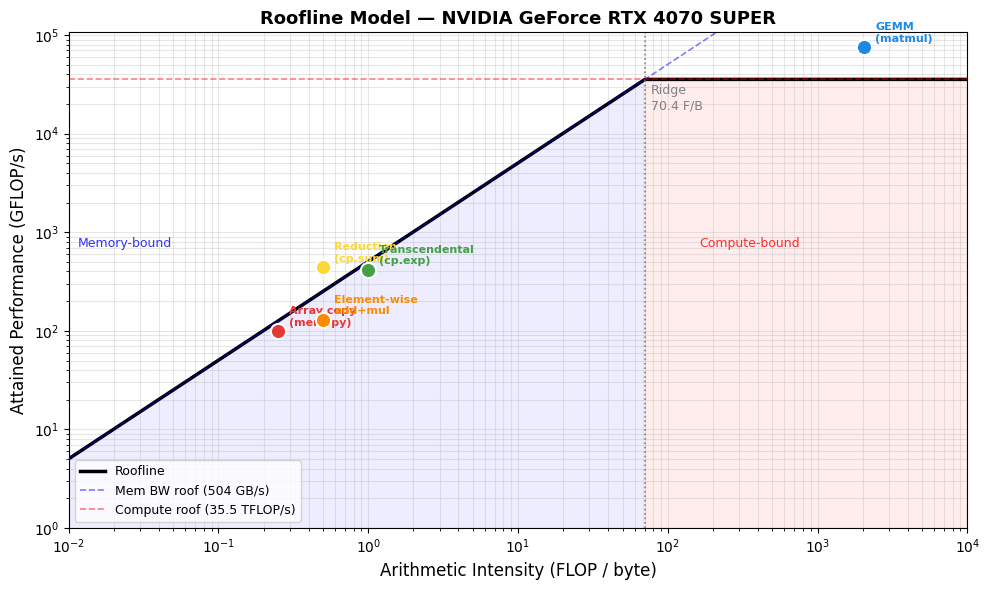

In [14]:
# ------------------------------------------------------------------
# Roofline Model — interactive chart for your GPU
# ------------------------------------------------------------------
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

# ── 1. Query GPU specs ─────────────────────────────────────────────
props       = cp.cuda.runtime.getDeviceProperties(0)
gpu_name    = props['name'].decode()
mem_bw_gbs  = props['memoryBusWidth'] * props['memoryClockRate'] * 2 / 8 / 1e6   # GB/s (theoretical)
sm_count    = props['multiProcessorCount']
# Approximate peak FP32 TFLOP/s (rough heuristic — replace with spec-sheet value if known)
clock_ghz   = props['clockRate'] / 1e6
cuda_cores_per_sm = 128          # Ampere/Ada; change to 64 for Turing
peak_tflops = sm_count * cuda_cores_per_sm * clock_ghz * 2 / 1e3   # FMA = 2 FLOPs

peak_gflops  = peak_tflops * 1000
ridge_point  = peak_gflops / mem_bw_gbs   # FLOP/byte

print(f"GPU               : {gpu_name}")
print(f"SMs               : {sm_count}")
print(f"Peak BW (theor.)  : {mem_bw_gbs:.0f} GB/s")
print(f"Peak FP32 (approx): {peak_tflops:.1f} TFLOP/s")
print(f"Ridge point       : {ridge_point:.1f} FLOP/byte")

# ── 2. Measure representative kernels ─────────────────────────────
N = 1 << 24

def measure(fn, ai_flops_per_byte_hint, label, repeats=50):
    for _ in range(3): fn()
    cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats): fn()
    cp.cuda.Stream.null.synchronize()
    elapsed = (time.perf_counter() - t0) / repeats
    return label, ai_flops_per_byte_hint, elapsed

a = cp.random.rand(N, dtype=cp.float32)
b = cp.random.rand(N, dtype=cp.float32)
M_sq = 4096
A2d  = cp.random.rand(M_sq, M_sq, dtype=cp.float32)
B2d  = cp.random.rand(M_sq, M_sq, dtype=cp.float32)

kernels = [
    # (label, fn, AI estimate)
    ("Array copy\n(memcpy)",     lambda: cp.copyto(b, a),         0.25),
    ("Element-wise\nadd+mul",    lambda: cp.add(a, b, out=b),     0.5 ),
    ("Reduction\n(cp.sum)",      lambda: cp.sum(a),               0.5 ),
    ("Transcendental\n(cp.exp)", lambda: cp.exp(a, out=b),        1.0 ),
    ("GEMM\n(matmul)",           lambda: cp.dot(A2d, B2d),        M_sq/2),
]

measured_points = []
for label, fn, ai in kernels:
    _, _, elapsed = measure(fn, ai, label)
    # Estimate attained GFLOP/s from known or estimated AI
    bytes_moved = N * 4 * 2 if "copy" in label or "add" in label or "Reduction" in label or "exp" in label \
                  else M_sq**2 * 4 * 3
    flops       = ai * bytes_moved
    gflops      = flops / elapsed / 1e9
    measured_points.append((label, ai, gflops))
    print(f"  {label.replace(chr(10),' '):30s}  AI≈{ai:6.2f}  {gflops:8.1f} GFLOP/s")

# ── 3. Plot Roofline ───────────────────────────────────────────────
ai_range = np.logspace(-2, 4, 500)
memory_roof  = mem_bw_gbs  * ai_range
compute_roof = np.full_like(ai_range, peak_gflops)
roofline     = np.minimum(memory_roof, compute_roof)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(ai_range, roofline, "k-",  linewidth=2.5, label="Roofline")
ax.loglog(ai_range, memory_roof,  "b--", linewidth=1.2, alpha=0.5, label=f"Mem BW roof ({mem_bw_gbs:.0f} GB/s)")
ax.axhline(peak_gflops, color="r", linestyle="--", linewidth=1.2, alpha=0.5,
           label=f"Compute roof ({peak_tflops:.1f} TFLOP/s)")
ax.axvline(ridge_point, color="gray", linestyle=":", linewidth=1.2)
ax.text(ridge_point * 1.1, peak_gflops * 0.5, f"Ridge\n{ridge_point:.1f} F/B",
        color="gray", fontsize=9)

colors = ["#e53935","#fb8c00","#fdd835","#43a047","#1e88e5"]
for (label, ai, gflops), color in zip(measured_points, colors):
    ax.scatter(ai, gflops, s=120, color=color, zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(label, (ai, gflops),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8, color=color, fontweight="bold")

ax.set_xlabel("Arithmetic Intensity (FLOP / byte)", fontsize=12)
ax.set_ylabel("Attained Performance (GFLOP/s)", fontsize=12)
ax.set_title(f"Roofline Model — {gpu_name}", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
ax.set_xlim(ai_range[0], ai_range[-1])
ax.set_ylim(1, peak_gflops * 3)

# Shade regions
ax.fill_between(ai_range[ai_range <= ridge_point],
                1, roofline[ai_range <= ridge_point],
                alpha=0.07, color="blue", label="Memory-bound region")
ax.fill_between(ai_range[ai_range >= ridge_point],
                1, roofline[ai_range >= ridge_point],
                alpha=0.07, color="red")
ax.text(ai_range[5],   peak_gflops * 0.02, "Memory-bound",  color="blue", fontsize=9, alpha=0.8)
ax.text(ai_range[350], peak_gflops * 0.02, "Compute-bound", color="red",  fontsize=9, alpha=0.8)

plt.tight_layout()
plt.show()


### 🏋️ Challenge 2-4 — Place Your Kernel on the Roofline

**Objective:** Implement a kernel, measure its true performance, and plot it on the roofline chart above.

**Your Task:**
Implement a **SAXPY** kernel (`y = α·x + y`) and a **dot product** kernel, then locate them on the roofline.

| Kernel | FLOP count | Bytes transferred | Arithmetic Intensity |
|---|---|---|---|
| SAXPY `y = α·x + y` | `2N` | `3N × 4` (read x, read y, write y) | `2/(3×4) ≈ 0.17 F/B` |
| Dot product `Σ xᵢyᵢ` | `2N` | `2N × 4` (read x, read y) | `2/(2×4) = 0.25 F/B` |

**Steps:**
1. Write both kernels as `cp.RawKernel` (or use CuPy built-ins).
2. Measure wall time (≥50 repeats, post-warm-up).
3. Compute **attained GFLOP/s** = `(2 × N) / elapsed / 1e9`.
4. Add both kernels as scatter points to the roofline chart using the AI values from the table.
5. Are they memory-bound or compute-bound? Does the roofline agree with your intuition?

**Bonus:** Try with `float16` — does it shift the ridge point?


In [15]:
# 🏋️ Challenge 2-4 — Your solution here
# ---------------------------------------------------------------
N       = 1 << 25      # 32 M floats
THREADS = 256
BLOCKS  = (N + THREADS - 1) // THREADS
ALPHA   = cp.float32(2.5)

# Step 1: SAXPY kernel
# saxpy_kernel = cp.RawKernel(r"""
# extern "C" __global__
# void saxpy(float alpha, const float* x, float* y, int n) {
#     int i = blockDim.x * blockIdx.x + threadIdx.x;
#     if (i < n) y[i] = alpha * x[i] + y[i];
# }
# """, "saxpy")

# Step 2: Dot product kernel  (hint: use atomicAdd for partial sums)
# dot_kernel = cp.RawKernel(r"""...""", "dot_product")

# Step 3: Benchmark both
# x = cp.random.rand(N, dtype=cp.float32)
# y = cp.random.rand(N, dtype=cp.float32)
# ...

# Step 4: Compute AI and attained GFLOP/s
# ai_saxpy = 2 / (3 * 4)
# ai_dot   = 2 / (2 * 4)
# gflops_saxpy = (2 * N) / t_saxpy / 1e9
# gflops_dot   = (2 * N) / t_dot   / 1e9

# Step 5: Add to roofline plot
# (copy the roofline plotting code from cell above and add your points)


---
## 📖 Resources

### Official Documentation
| Resource | Link |
|---|---|
| **CUDA C++ Programming Guide** — Memory Hierarchy | [docs.nvidia.com/cuda/cuda-c-programming-guide](https://docs.nvidia.com/cuda/cuda-c-programming-guide/index.html#memory-hierarchy) |
| **CuPy RawKernel docs** | [docs.cupy.dev/en/stable/user_guide/kernel.html](https://docs.cupy.dev/en/stable/user_guide/kernel.html) |
| **NVIDIA Ada Lovelace Architecture Whitepaper** | [nvidia.com/content/PDF/nvidia-ada-gpu-architecture](https://images.nvidia.com/arachnoid/us/assets/pdfs/NVIDIA_Ada_GPU_Architecture_Whitepaper_v2.1.pdf) |
| **CUDA Best Practices Guide** — Memory Optimizations | [docs.nvidia.com/cuda/cuda-c-best-practices-guide](https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/index.html#memory-optimizations) |

### Further Reading
- 📄 **"Roofline: An Insightful Visual Performance Model"** — Williams et al., 2009 — the original paper
- 📄 **NVIDIA Nsight Compute** — profiles your kernels and overlays them on the roofline automatically
- 🎥 **GTC Talk: "Memory-Centric GPU Architecture"** — search on [nvidia.com/gtc](https://www.nvidia.com/gtc)

### Key Mental Models to Remember
> 🧠 **"If you're memory-bound, optimise access patterns first — more compute won't help."**

> 🧠 **"Pinned memory is free performance for large transfers — just don't hoard it."**

> 🧠 **"Unified Memory is a convenience, not a performance feature — always prefetch."**

---
## ⏭️ Module 3 Preview — Warp-Level Programming
- **Warp divergence** — why `if/else` in a kernel is dangerous
- **Shuffle instructions** — `__shfl_xor_sync` for warp-level reductions
- **Occupancy** — packing more warps onto an SM
- **Tensor Cores** — matrix math at insane TFLOP/s
- **CUDA Graphs** — eliminating kernel launch overhead
